# Evaluate direction model — osc_next MuonGun DB

Plots results from `train_dynedge_muongun_neutrino.py`. No graphnet/IceCube dependencies needed.

Run training first:
```bash
python train_dynedge_muongun_neutrino.py
```

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/groups/icecube/holgerkc/Thesis_Analysis/Classifiers/finding_the_angles/dynedge_muongun_neutrino")
PREFIX = "dynedge_muongun_neutrino"

results = pd.read_csv(OUTPUT_DIR / f"{PREFIX}_results.csv")
metrics = json.loads((OUTPUT_DIR / f"{PREFIX}_metrics.json").read_text())
train_config = json.loads((OUTPUT_DIR / f"{PREFIX}_train_config.json").read_text())

print(f"Test events: {len(results)}")
print(f"Training: epochs={train_config['epochs']}, events={train_config['max_events']}, batch_size={train_config['batch_size']}")
print(f"Features: {train_config['features']}")
print(f"Split: train={train_config['n_train']}, val={train_config['n_val']}, test={train_config['n_test']}")

Test events: 500
Training: epochs=20, events=5000, batch_size=64
Features: ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'rde', 'pmt_area']
Split: train=4000, val=500, test=500


---
## Metrics summary

In [2]:
print(json.dumps(metrics, indent=2))

{
  "n_test": 500,
  "azimuth_mae_deg": 87.96511476708031,
  "zenith_mae_deg": 73.04539448334515,
  "opening_mae_deg": 75.9329441758565,
  "azimuth_median_deg": 85.58942540417756,
  "zenith_median_deg": 70.9890557217501,
  "opening_median_deg": 72.85552796218458,
  "opening_q68_deg": 91.49023419408965,
  "opening_q90_deg": 126.0434518093971,
  "opening_q95_deg": 143.23735441086282
}


---
## Error distributions

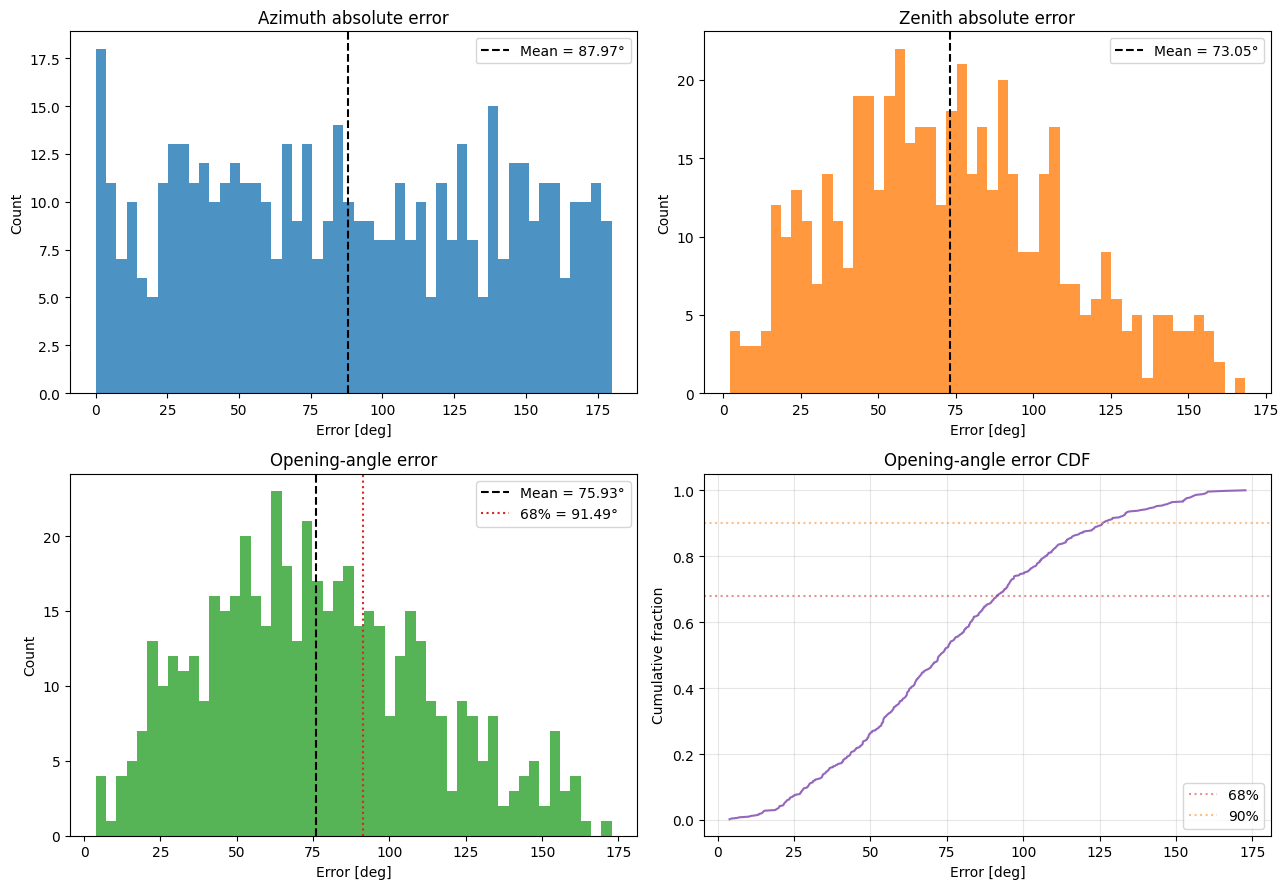

In [3]:
az_err = results["azimuth_abs_err_deg"].to_numpy()
ze_err = results["zenith_abs_err_deg"].to_numpy()
op_err = results["opening_angle_err_deg"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Azimuth error
axes[0, 0].hist(az_err, bins=50, color="tab:blue", alpha=0.8)
axes[0, 0].axvline(np.mean(az_err), color="black", ls="--", label=f"Mean = {np.mean(az_err):.2f}\u00b0")
axes[0, 0].set_title("Azimuth absolute error")
axes[0, 0].set_xlabel("Error [deg]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# Zenith error
axes[0, 1].hist(ze_err, bins=50, color="tab:orange", alpha=0.8)
axes[0, 1].axvline(np.mean(ze_err), color="black", ls="--", label=f"Mean = {np.mean(ze_err):.2f}\u00b0")
axes[0, 1].set_title("Zenith absolute error")
axes[0, 1].set_xlabel("Error [deg]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# Opening angle error
axes[1, 0].hist(op_err, bins=50, color="tab:green", alpha=0.8)
axes[1, 0].axvline(np.mean(op_err), color="black", ls="--", label=f"Mean = {np.mean(op_err):.2f}\u00b0")
axes[1, 0].axvline(np.quantile(op_err, 0.68), color="tab:red", ls=":", label=f"68% = {np.quantile(op_err, 0.68):.2f}\u00b0")
axes[1, 0].set_title("Opening-angle error")
axes[1, 0].set_xlabel("Error [deg]")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# Opening angle CDF
x_cdf = np.sort(op_err)
y_cdf = np.arange(1, len(x_cdf) + 1) / len(x_cdf)
axes[1, 1].plot(x_cdf, y_cdf, color="tab:purple")
axes[1, 1].axhline(0.68, color="tab:red", ls=":", alpha=0.5, label="68%")
axes[1, 1].axhline(0.90, color="tab:orange", ls=":", alpha=0.5, label="90%")
axes[1, 1].set_title("Opening-angle error CDF")
axes[1, 1].set_xlabel("Error [deg]")
axes[1, 1].set_ylabel("Cumulative fraction")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Opening angle vs energy

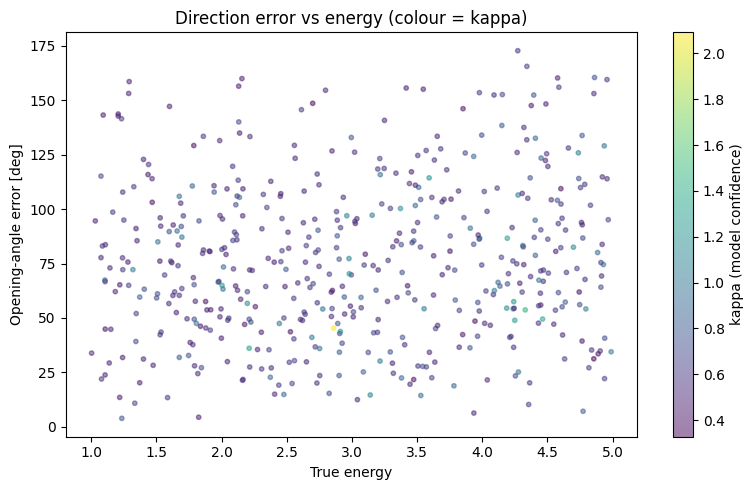

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    results["energy"], op_err,
    c=results["direction_kappa_pred"], cmap="viridis", alpha=0.5, s=10,
)
ax.set_xlabel("True energy")
ax.set_ylabel("Opening-angle error [deg]")
ax.set_title("Direction error vs energy (colour = kappa)")
plt.colorbar(sc, label="kappa (model confidence)")
plt.tight_layout()
plt.show()

---
## Uncertainty calibration: kappa vs angular error

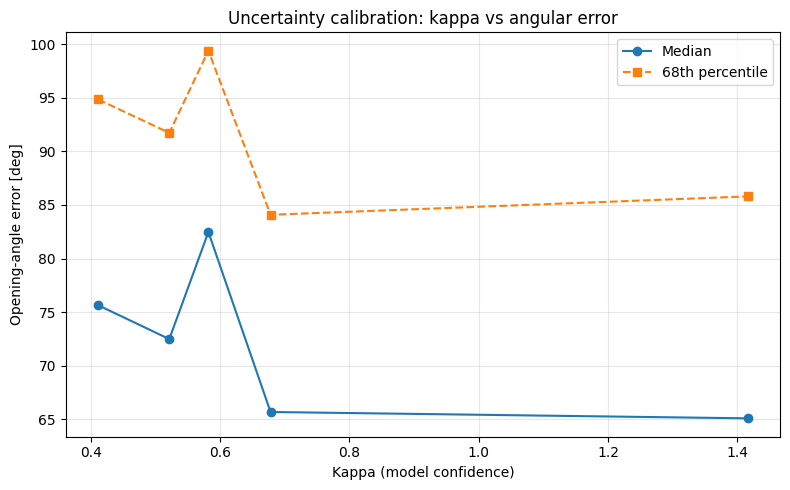

In [5]:
kappa = results["direction_kappa_pred"].to_numpy()
kappa_bins = np.quantile(kappa, np.linspace(0, 1, 6))

fig, ax = plt.subplots(figsize=(8, 5))
bin_centers = []
bin_medians = []
bin_q68 = []

for i in range(len(kappa_bins) - 1):
    mask = (kappa >= kappa_bins[i]) & (kappa < kappa_bins[i + 1])
    if i == len(kappa_bins) - 2:
        mask = (kappa >= kappa_bins[i]) & (kappa <= kappa_bins[i + 1])
    if mask.sum() == 0:
        continue
    bin_centers.append((kappa_bins[i] + kappa_bins[i + 1]) / 2)
    bin_medians.append(np.median(op_err[mask]))
    bin_q68.append(np.quantile(op_err[mask], 0.68))

ax.plot(bin_centers, bin_medians, "o-", label="Median")
ax.plot(bin_centers, bin_q68, "s--", label="68th percentile")
ax.set_xlabel("Kappa (model confidence)")
ax.set_ylabel("Opening-angle error [deg]")
ax.set_title("Uncertainty calibration: kappa vs angular error")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Per-particle-type performance

In [6]:
pid_names = {
    12: "nu_e", -12: "nu_e_bar",
    14: "nu_mu", -14: "nu_mu_bar",
    16: "nu_tau", -16: "nu_tau_bar",
    13: "mu", -13: "mu_bar",
    -1: "muongun",
}

print(f"{'Particle':>12s}  {'pid':>5s}  {'N':>5s}  {'Median [deg]':>12s}  {'q68 [deg]':>10s}")
print("-" * 55)
for pid_val in sorted(results["pid"].unique()):
    mask = results["pid"] == pid_val
    n = mask.sum()
    if n == 0:
        continue
    med = np.median(results.loc[mask, "opening_angle_err_deg"])
    q68 = np.quantile(results.loc[mask, "opening_angle_err_deg"], 0.68)
    name = pid_names.get(int(pid_val), str(int(pid_val)))
    print(f"{name:>12s}  {int(pid_val):>5d}  {n:>5d}  {med:>12.2f}  {q68:>10.2f}")

    Particle    pid      N  Median [deg]   q68 [deg]
-------------------------------------------------------
   nu_mu_bar    -14    154         74.03       91.50
       nu_mu     14    346         72.24       91.34
